# Análise de Medalhas

- Quadro de Medalhas dos Países (Total de Medalhas nos Jogos de Verão e Inverno)
- Top 50 Países no Total de Medalhas

In [38]:
import pandas as pd
import os
import shutil

import json
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
from matplotlib.container import BarContainer
import seaborn as sns

## Abertura do dataset

In [9]:
caminho_arquivo = "../../bronze/olympics_medals.parquet"

print(os.listdir("../../bronze"))

['olympics_athletes.json', 'olympics_athletes.parquet', 'olympics_medals.json', 'olympics_medals.parquet', 'olympics_sports.json', 'olympics_sports.parquet']


In [16]:
df_medals = pd.read_parquet(caminho_arquivo, engine="pyarrow")

df_medals.head()

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896,Summer Olympics,1,Greece,GRE,10,18,19,47
1,1900,Summer Olympics,2,France,FRA,31,41,40,112
2,1900,Summer Olympics,2,United States,USA,20,13,15,48
3,1904,Summer Olympics,3,United States,USA,80,85,83,248
4,1908,Summer Olympics,5,Great Britain,GBR,56,51,39,146


## Tabela e Visualização

In [17]:
df_total = df_medals[df_medals['edition'].isin(['Summer Olympics', 'Winter Olympics'])]

df_total = (
    df_total.groupby('country')[['gold', 'silver', 'bronze', 'total']]
    .sum()
    .sort_values('total', ascending=False)
)

df_total.head(5)

,gold,silver,bronze,total
country,,,,
United States,1223,1007,881,3111
Soviet Union,473,376,355,1204
Great Britain,317,350,359,1026
Germany,327,324,328,979
France,288,325,362,975


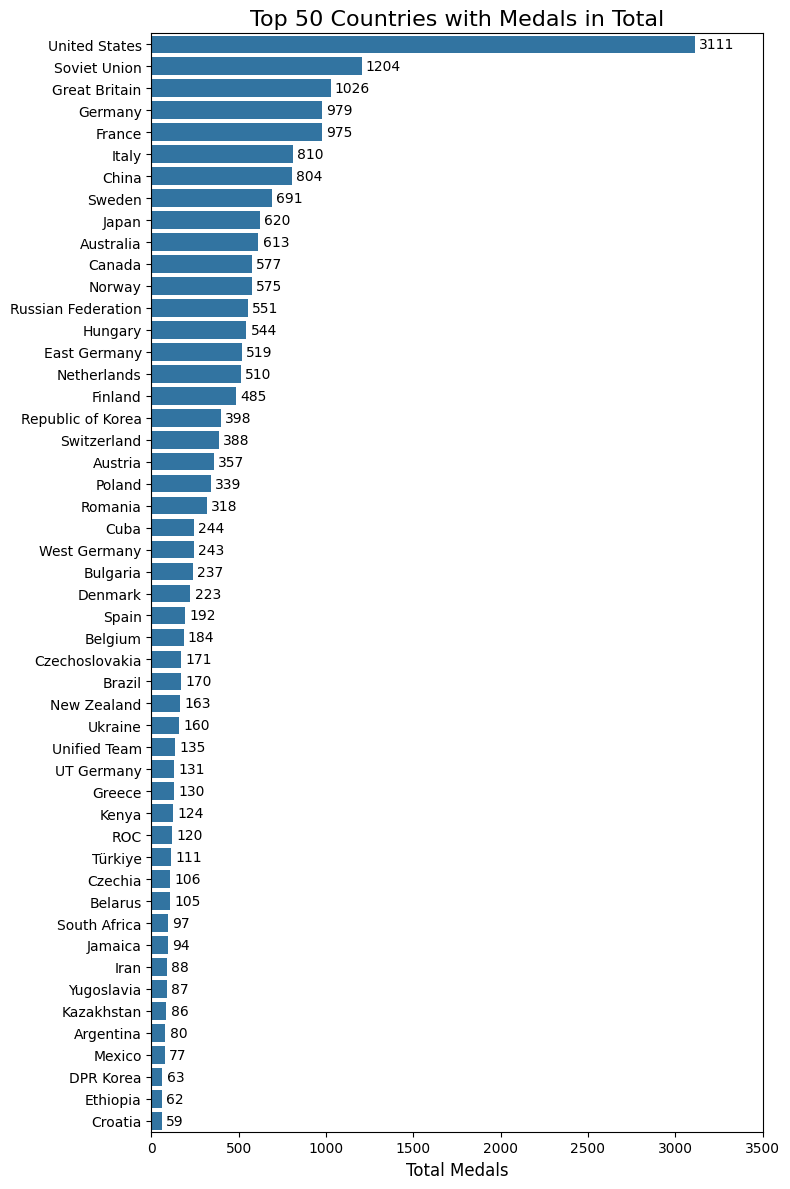

In [29]:
plt.figure(figsize=(8, 12))

ax = sns.barplot(x=df_total.head(50)['total'],
                 y=df_total.head(50).index,
                 orient='h')

ax.bar_label((ax.containers[0]), color='black', padding=3)

ax.set_title("Top 50 Countries with Medals in Total", fontsize=16)
ax.set_xlabel('Total Medals', fontsize=12)
ax.set_xlim(0, 3500)
ax.set_ylabel("")

plt.tight_layout()

plt.show()

## Salvando arquivo e metadados

In [ ]:
# Salvando o dataset processado em CSV
df_total.reset_index().to_csv("medals_summary.csv", index=True)

In [ ]:
metadado = {
    "nome": "Total de Medalhas Olímpicas por País",
    "fonte": "olympic_medals.parquet",
    "descricao": "Contagem de Bronzes, Pratas, Ouro e Total por País",
    "campos": [
        "country",
        "gold",
        "silver",
        "bronze",
        "total"
    ],
    "data_coleta": datetime.now().strftime("%d-%m-%Y"),
    "observacoes": "A contagem é referente aos Jogos Olímpicos de Verão e Inverno"
}

In [41]:
caminho_metadata = "medals_summary.json"

with open(caminho_metadata, "w", encoding='utf-8') as f:
    json.dump(metadado, f, ensure_ascii=False, indent=4)